# Classic ML Sklearn approach BEST RESULT

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

print("Loading and preprocessing data...")

X_raw = []
y_raw = []

with open('data/combined48.txt', 'r') as file:
    for line in file:
        values = line.strip().split()
        
        if len(values) == 584:
            numeric_values = [float(val) for val in values]
            
            # check attribute a1 (index 576): 1 = face, 0 = no face
            if numeric_values[576] == 1.0:
                pixels = numeric_values[:576]
                X_raw.append(pixels)
                
                # extract attribute a3 (index 578): Person ID
                label = int(numeric_values[578])
                y_raw.append(label)

X = np.array(X_raw)
y = np.array(y_raw)
print(f"Successfully loaded {X.shape[0]} valid images.")

# split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- training Random Forest ---")
rf_model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=None, 
    min_samples_split=2, 
    random_state=42
)


rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Final Random Forest Accuracy: {rf_accuracy * 100:.2f}%")


print("\n--- Training the Ultimate Neural Network ---")

ann_model_ultimate = MLPClassifier(
    hidden_layer_sizes=(512, 256),   # bigger
    activation='relu',               # standard, fast activation
    solver='adam',                   # best overall optimizer
    alpha=0.05,                      # stronger regularization to prevent overfitting
    learning_rate='adaptive',        # shifts gears to make fine-tuned adjustments
    max_iter=1000,                   # let it cook
    random_state=42
)

# neural networks need the scaled data
ann_model_ultimate.fit(X_train_scaled, y_train)

# make predictions
ann_ultimate_predictions = ann_model_ultimate.predict(X_test_scaled)

# calculate accuracy
ann_accuracy = accuracy_score(y_test, ann_ultimate_predictions)
print(f" Ultimate Neural Network Accuracy: {ann_accuracy * 100:.2f}%")

print("\nDetailed Report:")
print(classification_report(y_test, ann_ultimate_predictions, zero_division=0))

# --- training Random Forest ---
# Final Random Forest Accuracy: 70.59%

# --- Training the Ultimate Neural Network ---
#  Ultimate Neural Network Accuracy: 85.88%

Loading and preprocessing data...
Successfully loaded 6835 valid images.

--- training Random Forest ---
Final Random Forest Accuracy: 70.59%

--- Training the Ultimate Neural Network ---
 Ultimate Neural Network Accuracy: 85.88%

Detailed Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.83        32
           1       0.90      0.85      0.87        52
           2       0.85      0.85      0.85        27
           3       0.87      0.84      0.86        32
           4       1.00      0.76      0.87        17
           5       0.73      0.80      0.76        20
           6       0.83      0.89      0.86        27
           7       0.95      0.86      0.90        22
           8       0.83      0.85      0.84        34
           9       0.89      0.81      0.85        21
          10       0.86      0.91      0.88        33
          11       0.90      0.92      0.91        38
          12       0.81      0.89      0.85      

# Classic ML Sklearn approach with augmentation (mirror flipping) 10k images BEST RESULT

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Loading raw 576-pixel data...")

X_raw = []
y_raw = []

with open('data/combined48.txt', 'r') as file:
    for line in file:
        values = line.strip().split()
        if len(values) == 584:
            numeric_values = [float(val) for val in values]
            # Check attribute a1: 1 = face
            if numeric_values[576] == 1.0:
                X_raw.append(numeric_values[:576])
                y_raw.append(int(numeric_values[578]))

X = np.array(X_raw)
y = np.array(y_raw)
print(f"Successfully loaded {X.shape[0]} images.")

# 1. split the data FIRST 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original Training Size: {X_train.shape[0]} images")

# --- DATA AUGMENTATION (Horizontal Flipping) ---
print("Augmenting data... (Flipping images horizontally)")
X_train_augmented = list(X_train)
y_train_augmented = list(y_train)

for i in range(len(X_train)):
    # reshape the flat 576 array back into a 24x24 picture
    img_2d = X_train[i].reshape(24, 24)
    
    # flip it like a mirror
    img_flipped = np.fliplr(img_2d)
    
    # flatten it back to 576 and add it to our training pool
    X_train_augmented.append(img_flipped.flatten())
    y_train_augmented.append(y_train[i]) # add the same label

# convert back to numpy arrays for the model
X_train = np.array(X_train_augmented)
y_train = np.array(y_train_augmented)

print(f"New Augmented Training Size: {X_train.shape[0]} images!")

# 2. scale the newly massive dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- training Random Forest ---")
rf_model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=None, 
    min_samples_split=2, 
    random_state=42
)


rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Final Random Forest Accuracy: {rf_accuracy * 100:.2f}%")


print("\n--- Training the Ultimate Neural Network ---")

ann_model_ultimate = MLPClassifier(
    hidden_layer_sizes=(512, 256),  
    activation='relu',               
    solver='adam',                  
    alpha=0.05,                      
    learning_rate='adaptive',        
    max_iter=1000,                   
    random_state=42
)


# neural networks need the scaled data
ann_model_ultimate.fit(X_train_scaled, y_train)

# make predictions
ann_ultimate_predictions = ann_model_ultimate.predict(X_test_scaled)

# calculate accuracy
ann_accuracy = accuracy_score(y_test, ann_ultimate_predictions)
print(f" Ultimate Neural Network Accuracy: {ann_accuracy * 100:.2f}%")

print("\nDetailed Report:")
print(classification_report(y_test, ann_ultimate_predictions, zero_division=0))

# New Augmented Training Size: 10936 images!

# --- training Random Forest ---
# Final Random Forest Accuracy: 71.69%

# --- Training the Ultimate Neural Network ---
#  Ultimate Neural Network Accuracy: 86.17%

Loading raw 576-pixel data...
Successfully loaded 6835 images.
Original Training Size: 5468 images
Augmenting data... (Flipping images horizontally)
New Augmented Training Size: 10936 images!

--- training Random Forest ---
Final Random Forest Accuracy: 71.69%

--- Training the Ultimate Neural Network ---
 Ultimate Neural Network Accuracy: 86.17%

Detailed Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        32
           1       0.94      0.87      0.90        52
           2       0.85      0.81      0.83        27
           3       0.96      0.81      0.88        32
           4       0.88      0.82      0.85        17
           5       0.82      0.70      0.76        20
           6       0.83      0.89      0.86        27
           7       0.90      0.82      0.86        22
           8       0.91      0.85      0.88        34
           9       0.86      0.90      0.88        21
          10       0.88      0.91     

# Classic ML Sklearn approach with augmentation (pixel shifting) 27k images BEST RESULT

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy.ndimage import shift
from sklearn.ensemble import RandomForestClassifier

print("Loading and preprocessing data...")

X_raw = []
y_raw = []

with open('data/combined48.txt', 'r') as file:
    for line in file:
        values = line.strip().split()
        
        if len(values) == 584:
            numeric_values = [float(val) for val in values]
            
            # check attribute a1 (index 576): 1 = face, 0 = no face
            if numeric_values[576] == 1.0:
                pixels = numeric_values[:576]
                X_raw.append(pixels)
                
                # extract attribute a3 (index 578): Person ID
                label = int(numeric_values[578])
                y_raw.append(label)

X = np.array(X_raw)
y = np.array(y_raw)
print(f"Successfully loaded {X.shape[0]} valid images.")

# split the data first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original Training Size: {X_train.shape[0]} images")

# --- Pixel Shifting ---
print("Augmenting data by shifting pixels (This expands the dataset by 5x)...")

X_train_augmented = list(X_train)
y_train_augmented = list(y_train)

for i in range(len(X_train)):
    # reshape to 24x24 for spatial shifting
    img_2d = X_train[i].reshape(24, 24)
    
    # create shifted versions (filling the empty edge pixels with 0, which is black)
    shifted_up = shift(img_2d, [-1, 0], cval=0.0) 
    shifted_down = shift(img_2d, [1, 0], cval=0.0) 
    shifted_left = shift(img_2d, [0, -1], cval=0.0) 
    shifted_right = shift(img_2d, [0, 1], cval=0.0)
    
    # flatten and append them to the training pool
    X_train_augmented.extend([
        shifted_up.flatten(), 
        shifted_down.flatten(), 
        shifted_left.flatten(), 
        shifted_right.flatten()
    ])
    
    # append the same label 4 times for the 4 new shifted images
    y_train_augmented.extend([y_train[i]] * 4)

X_train = np.array(X_train_augmented)
y_train = np.array(y_train_augmented)

print(f"New Augmented Training Size: {X_train.shape[0]} images. Training will take a bit longer.")

# scale the massively expanded dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- training Random Forest ---")
rf_model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=None, 
    min_samples_split=2, 
    random_state=42
)


rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Final Random Forest Accuracy: {rf_accuracy * 100:.2f}%")


print("\n--- Training the Ultimate Neural Network ---")
ann_model_ultimate = MLPClassifier(
    hidden_layer_sizes=(512, 256),   
    activation='relu',               
    solver='adam',                   
    alpha=0.05,                      
    learning_rate='adaptive',        
    max_iter=1000,                   
    random_state=42
)

ann_model_ultimate.fit(X_train_scaled, y_train)

# make predictions
ann_ultimate_predictions = ann_model_ultimate.predict(X_test_scaled)

# calculate accuracy
ann_accuracy = accuracy_score(y_test, ann_ultimate_predictions)
print(f"Ultimate Neural Network Accuracy: {ann_accuracy * 100:.2f}%")

# New Augmented Training Size: 27340 images. Training will take a bit longer.

# --- training Random Forest ---
# Final Random Forest Accuracy: 73.74%

# --- training Random Forest ---
# Final Random Forest Accuracy: 73.74%

# --- Training the Ultimate Neural Network ---
# Ultimate Neural Network Accuracy: 88.51%

Loading and preprocessing data...
Successfully loaded 6835 valid images.
Original Training Size: 5468 images
Augmenting data by shifting pixels (This expands the dataset by 5x)...
New Augmented Training Size: 27340 images. Training will take a bit longer.

--- training Random Forest ---
Final Random Forest Accuracy: 73.74%

--- Training the Ultimate Neural Network ---
Ultimate Neural Network Accuracy: 88.51%


# Classic ML Sklearn approach with augmentation (mirror flipping) 27k images + HOG BEST RESULT

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import hog
from scipy.ndimage import shift

print("Loading raw pixel data...")

X_raw = []
y_raw = []

# 1. LOAD RAW PIXELS ONLY
with open(r'data/combined48.txt', 'r') as file:
    for line in file:
        values = line.strip().split()
        if len(values) == 584:
            numeric_values = [float(val) for val in values]
            if numeric_values[576] == 1.0:
                X_raw.append(numeric_values[:576])
                y_raw.append(int(numeric_values[578]))

X = np.array(X_raw)
y = np.array(y_raw)
print(f"Successfully loaded {X.shape[0]} valid images.")

# 2. SPLIT FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Original Training Size: {X_train.shape[0]} images")

# 3. AUGMENT RAW PIXELS (Shifting)
print("Augmenting data by shifting pixels...")
X_train_augmented = list(X_train)
y_train_augmented = list(y_train)

for i in range(len(X_train)):
    img_2d = X_train[i].reshape(24, 24)
    
    shifted_up = shift(img_2d, [-1, 0], cval=0.0)
    shifted_down = shift(img_2d, [1, 0], cval=0.0)
    shifted_left = shift(img_2d, [0, -1], cval=0.0)
    shifted_right = shift(img_2d, [0, 1], cval=0.0)
    
    X_train_augmented.extend([
        shifted_up.flatten(), 
        shifted_down.flatten(), 
        shifted_left.flatten(), 
        shifted_right.flatten()
    ])
    y_train_augmented.extend([y_train[i]] * 4)

X_train_aug_arr = np.array(X_train_augmented)
y_train = np.array(y_train_augmented)
print(f"New Augmented Training Size: {X_train_aug_arr.shape[0]} images.")

# 4. EXTRACT HOG FEATURES FROM THE AUGMENTED DATA
print("Extracting HOG features from Training Set...")
X_train_hog = []
for pixels in X_train_aug_arr:
    img_2d = pixels.reshape((24, 24))
    features = hog(img_2d, orientations=8, pixels_per_cell=(4, 4), cells_per_block=(2, 2), visualize=False)
    X_train_hog.append(features)
X_train_hog = np.array(X_train_hog)

print("Extracting HOG features from Test Set...")
X_test_hog = []
for pixels in X_test:
    img_2d = pixels.reshape((24, 24))
    features = hog(img_2d, orientations=8, pixels_per_cell=(4, 4), cells_per_block=(2, 2), visualize=False)
    X_test_hog.append(features)
X_test_hog = np.array(X_test_hog)


# 5. SCALE THE HOG FEATURES
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)
X_test_scaled = scaler.transform(X_test_hog)


# 6. TRAIN MODELS
print("\n--- Training Random Forest (on HOG + Augmented Data) ---")
rf_model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=None, 
    min_samples_split=2, 
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Final Random Forest Accuracy: {rf_accuracy * 100:.2f}%")


print("\n--- Training Artificial Neural Network (on HOG + Augmented Data) ---")
ann_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),  
    activation='relu',              
    solver='adam',                  
    max_iter=500,                   
    random_state=42
)

ann_model.fit(X_train_scaled, y_train)
ann_predictions = ann_model.predict(X_test_scaled)
ann_accuracy = accuracy_score(y_test, ann_predictions)
print(f"Final Neural Network Accuracy: {ann_accuracy * 100:.2f}%")

# New Augmented Training Size: 27340 images.
# --- Training Random Forest (on HOG + Augmented Data) ---
# Final Random Forest Accuracy: 52.82%

# --- Training Artificial Neural Network (on HOG + Augmented Data) ---
# Final Neural Network Accuracy: 74.98%

Loading raw pixel data...
Successfully loaded 6835 valid images.
Original Training Size: 5468 images
Augmenting data by shifting pixels...
New Augmented Training Size: 27340 images.
Extracting HOG features from Training Set...
Extracting HOG features from Test Set...

--- Training Random Forest (on HOG + Augmented Data) ---
Final Random Forest Accuracy: 52.82%

--- Training Artificial Neural Network (on HOG + Augmented Data) ---
Final Neural Network Accuracy: 74.98%


# Deep Learning pytorch + augmentation (pixel shift) 27k images BEST RESULTS

Loading data for PyTorch CNN...
Successfully loaded 6835 images.
New Augmented Training Size: 27340 images. Training will take a bit longer.

--- Training CNN on: cpu ---
Epoch [1/30] - Loss: 1.8752 | Val Accuracy: 76.44%
Epoch [2/30] - Loss: 0.7534 | Val Accuracy: 86.17%
Epoch [3/30] - Loss: 0.4576 | Val Accuracy: 88.88%
Epoch [4/30] - Loss: 0.3211 | Val Accuracy: 90.49%
Epoch [5/30] - Loss: 0.2448 | Val Accuracy: 89.69%
Epoch [6/30] - Loss: 0.1951 | Val Accuracy: 89.83%
Epoch [7/30] - Loss: 0.1627 | Val Accuracy: 90.56%
Epoch [8/30] - Loss: 0.1491 | Val Accuracy: 90.71%
Epoch [9/30] - Loss: 0.1322 | Val Accuracy: 90.93%
Epoch [10/30] - Loss: 0.1120 | Val Accuracy: 91.00%
Epoch [11/30] - Loss: 0.1194 | Val Accuracy: 91.08%
Epoch [12/30] - Loss: 0.1038 | Val Accuracy: 91.29%
Epoch [13/30] - Loss: 0.0982 | Val Accuracy: 90.42%
Epoch [14/30] - Loss: 0.0893 | Val Accuracy: 91.44%
Epoch [15/30] - Loss: 0.0928 | Val Accuracy: 90.78%
Epoch [16/30] - Loss: 0.0895 | Val Accuracy: 91.44%
Epoch 

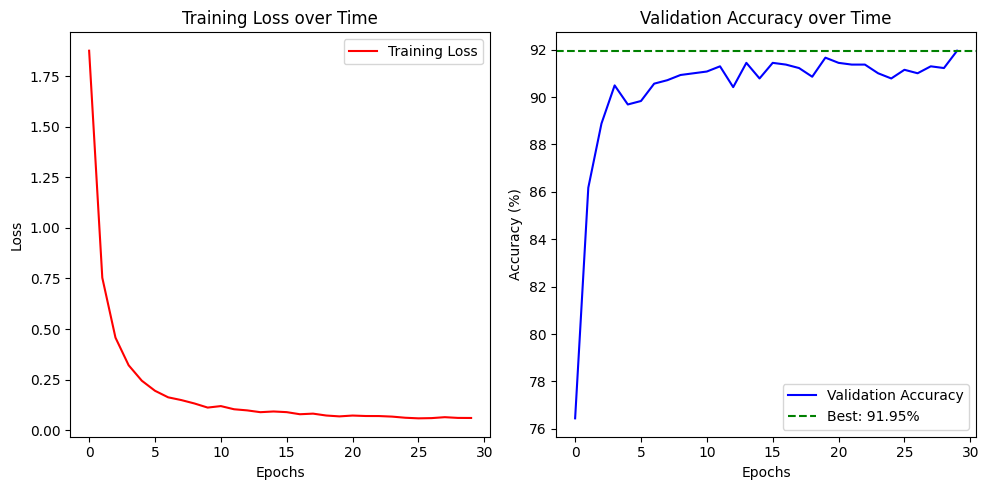

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from scipy.ndimage import shift
import copy

print("Loading data for PyTorch CNN...")

X_raw = []
y_raw = []

with open(r'data/combined48.txt', 'r') as file:
    for line in file:
        values = line.strip().split()
        if len(values) == 584:
            numeric_values = [float(val) for val in values]
            if numeric_values[576] == 1.0:
                X_raw.append(numeric_values[:576])
                y_raw.append(int(numeric_values[578]))

X = np.array(X_raw)
y = np.array(y_raw)
print(f"Successfully loaded {X.shape[0]} images.")

# 1. labels to be strictly 0 to (num_classes - 1)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

# 2. split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

X_train_augmented = list(X_train)
y_train_augmented = list(y_train)

for i in range(len(X_train)):
    # reshape to 24x24 for spatial shifting
    img_2d = X_train[i].reshape(24, 24)
    
    # Create shifted versions (filling the empty edge pixels with 0, which is black)
    shifted_up = shift(img_2d, [-1, 0], cval=0.0)
    shifted_down = shift(img_2d, [1, 0], cval=x``0.0)
    shifted_left = shift(img_2d, [0, -1], cval=0.0)
    shifted_right = shift(img_2d, [0, 1], cval=0.0)
    
    # flatten and append them to the training pool
    X_train_augmented.extend([
        shifted_up.flatten(), 
        shifted_down.flatten(), 
        shifted_left.flatten(), 
        shifted_right.flatten()
    ])
    
    # append the same label 4 times for the 4 new shifted images
    y_train_augmented.extend([y_train[i]] * 4)

X_train = np.array(X_train_augmented)
y_train = np.array(y_train_augmented)

print(f"New Augmented Training Size: {X_train.shape[0]} images. Training will take a bit longer.")

# scale the massively expanded dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. reshape into 2D matrices for the CNN
# shape requirement: (num of imgs, channels, h, w)
X_train_cnn = X_train_scaled.reshape(-1, 1, 24, 24)
X_test_cnn = X_test_scaled.reshape(-1, 1, 24, 24)

# 5. convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_cnn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_cnn, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 6. create DataLoaders (feeding data in batches of 64)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


# --- define the CNN architecture ---
class FaceCNN(nn.Module):
    def __init__(self, num_classes):
        super(FaceCNN, self).__init__()
        
        # layer 1:  edge detection and shadows
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # shrinks 24x24 to 12x12
        
        # layer 2: more complex shapes (eyes, noses)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # s  hrinks 12x12 to 6x6
        
        # layer 3:  standard NN brain on top
        self.flatten = nn.Flatten()
        
        # 64 channels * 6 height * 6 width flat features
        self.fc1 = nn.Linear(64 * 6 * 6, 512)
        self.relu3 = nn.ReLU()
        
        # dropout: randomly turns off 50% of neurons during training to prevent memorization
        self.dropout = nn.Dropout(0.5) 
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # pass data through the layers
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.fc2(x)
        return x


# --- setup training environment ---
# GPU (yeah sure) else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- Training CNN on: {device} ---")

model = FaceCNN(num_classes).to(device)

# loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

import matplotlib.pyplot as plt

# empty lists to store our data points for the graph
train_losses = []
val_accuracies = []

# --- variables to track the highest score ---
best_acc = 0.0
best_model_weights = None

epochs = 30
for epoch in range(epochs):
    model.train() # training mode
    running_loss = 0.0
    
    # --- TRAINING PHASE ---
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()               
        outputs = model(inputs)             
        loss = criterion(outputs, labels)   
        loss.backward()                     
        optimizer.step()                    
        
        running_loss += loss.item()
    
    # average loss for this epoch
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    
    # --- VALIDATION PHASE (checkin accuracy at the end of every epoch) ---
    model.eval() # turned off dropout for testing
    correct = 0
    total = 0
    
    with torch.no_grad():
        # feed the test data in
        test_inputs = X_test_tensor.to(device)
        test_labels = y_test_tensor.to(device)
        test_outputs = model(test_inputs)
        
        # here how many it got right
        _, predicted = torch.max(test_outputs.data, 1)
        total += test_labels.size(0)
        correct += (predicted == test_labels).sum().item()
        
    epoch_val_acc = (correct / total) * 100
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {epoch_loss:.4f} | Val Accuracy: {epoch_val_acc:.2f}%")
    
    # --- snapshot 
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        # deepcopy saves the exact internal dials at this specific moment
        best_model_weights = copy.deepcopy(model.state_dict()) 

# --- load the absolute best back into the model ---
print(f"\nTraining complete! Reloading the best brain... ")
model.load_state_dict(best_model_weights)
print(f"LOCKED IN ULTIMATE ACCURACY: {best_acc:.2f}%")

# --- DRAW THE GRAPH ---
plt.figure(figsize=(10, 5))

# plot 1: training loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='red')
plt.title('Training Loss over Time')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# plot 2: validation accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='blue')
# add a line showing exactly where the highest score was captured
plt.axhline(y=best_acc, color='green', linestyle='--', label=f'Best: {best_acc:.2f}%')
plt.title('Validation Accuracy over Time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()